In [2]:
import tensorflow

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls drive/MyDrive

'11.6. DSTL Assignment 4.pdf'
'11.7. DSTL Assignment 5.pdf'
 20190731001655.png
 8.-Chemical-Equilibrium_copy.pdf
 9d8bb7011a9445ad98c226b792991c8e.pdf
'AC circuit Analysis (Unit -2).pdf'
'AC fundamental (unit-2).pdf'
'Adobe Scan 02-Jul-2025.pdf'
'AI  U-1 Combined Notes_b6009542-a057-45ad-8c51-45dae356df5a.pdf'
'AI  U-2 Combined Notes_fde572ae-f590-4564-81d3-dd6841b6df1a.pdf'
'AJAX NOTES (1).pdf'
'AJAX NOTES.pdf'
'Attendance Bot.gscript'
'BCS063 21-22.pdf'
'BCS063 22-23.pdf'
'BCS063 24-25.pdf'
'BCS063 QB.pdf'
'BCS063 ST1 22-23.pdf'
'BCS063 ST2 24-25.pdf'
'BCS064 PUT 24-25.pdf'
 BCS402-THEORY-OF-AUTOMATA-AND-FORMAL-LANGUAGES.pdf
'BEE 201( Unit-1).pdf'
'BLOCKCHAIN UNIT 1 (1).pdf'
'BLOCKCHAIN UNIT 1 (2).pdf'
'BLOCKCHAIN UNIT 1.pdf'
'BOE061 UNIT 1.pdf'
'BOE061 UNIT 2 (1).pdf'
'BOE061 UNIT 2.pdf'
'BOE061 UNIT 3 (1).pdf'
'BOE061 UNIT 3.pdf'
'BOE061 UNIT 4 (1).pdf'
'BOE061 UNIT 4.pdf'
'BOE061 UNIT 5 (1).pdf'
'BOE061 UNIT 5.pdf'
'BOE061 UT 24-25.pdf'
'certificate (1).png'
 certificate.webp.png

In [5]:
!unzip "/content/drive/MyDrive/Copy of chest_xray-20250726T110654Z-1-001.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1258-0001-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1183-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1258-0001-0002.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1228-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1202-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1176-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1261-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1234-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1188-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1198-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1254-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMAL2-IM-1242-0001.jpeg  
  inflating: /content/chest_xray/train/NORMAL/NORMA

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [7]:
os.listdir('/content/')

['.config', 'chest_xray', 'drive', 'sample_data']

In [8]:
os.listdir('/content/chest_xray')

['model_10.h5',
 'model_vit_10.h5',
 'test',
 'custom_pre_trained_model_10.h5',
 'train',
 'val']

In [9]:
# setting the training data directory
DataDir = "/content/chest_xray/train"

In [10]:
! ls /content/chest_xray/test

NORMAL	PNEUMONIA


In [11]:
CATEGORIES = ['NORMAL','PNEUMONIA']

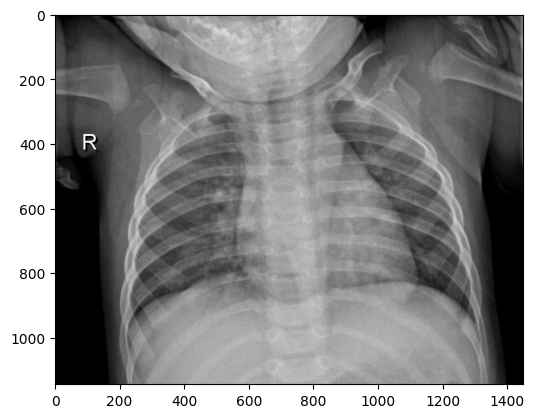

In [12]:
# converting the images into grayscale
for i in CATEGORIES:
  path = os.path.join(DataDir,i)
  for img in os.listdir(path):
    img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE) # Reads image in grayscale
    plt.imshow(img_array,cmap='gray')
    plt.show()
    break
  break

In [13]:
# initialising the size of the image so that every image should be in same dimension
img_size=100

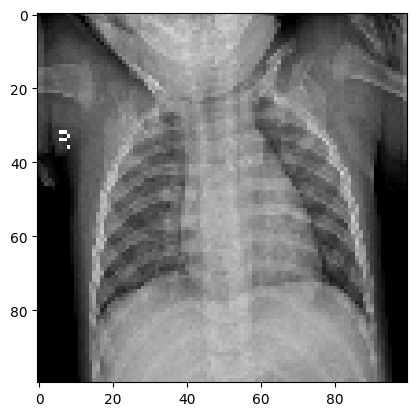

In [14]:
# image after resize and gray scale
new_array = cv2.resize(img_array,(img_size,img_size))
plt.imshow(new_array,cmap='gray')
plt.show()

In [15]:
training_data=[] # List to store data

In [16]:
# defining the function for training data according to the categories converting the images into gray scale with resizing the image into 100 x 100
# converting it into numpy arrays
def create_training_data():
    for i in CATEGORIES:

        path=os.path.join(DataDir,i)
        class_num=CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(img_size,img_size))
                training_data.append([new_array,class_num])  # Store [image, label]

            except Exception as e:
                pass  # Skip corrupted images


In [17]:
create_training_data()

import random
random.shuffle(training_data)
for sample in training_data[:10]:
    print(sample)

[array([[  1,   2,   1, ...,   1,   1,   1],
       [  2,   1,   1, ..., 235,  15,   1],
       [  2,   1,   1, ..., 248,   2,   1],
       ...,
       [  0,   0,   0, ..., 212, 249,  70],
       [  0,   0,   0, ..., 235, 252,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8), 1]
[array([[49, 58, 63, ..., 36, 27, 21],
       [51, 61, 62, ..., 36, 27, 19],
       [58, 62, 77, ..., 37, 30, 19],
       ...,
       [15, 37, 48, ..., 24, 24, 24],
       [15, 39, 51, ..., 24, 24, 24],
       [13, 45, 51, ..., 24, 24, 24]], dtype=uint8), 1]
[array([[48, 57, 69, ...,  0,  0,  0],
       [45, 53, 63, ...,  0,  0,  0],
       [37, 49, 57, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8), 0]
[array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 197, 199, 172],
       [224, 203, 195, ..., 146, 114, 107],
       ...,
       [  0,   0,   0, ...,  37,  44,  46]

In [18]:
X=[]
y=[]

# spliting the features and labels
for features,label in training_data:
    X.append(features)
    y.append(label)

print(X[0].reshape(-1,img_size,img_size,1))
y = np.array(y)
# reshapping the features for making it compatible with tensorflow
X = np.array(X).reshape(-1,img_size,img_size,1)
# -1 → auto size
# 1 → grayscale channel

[[[[  1]
   [  2]
   [  1]
   ...
   [  1]
   [  1]
   [  1]]

  [[  2]
   [  1]
   [  1]
   ...
   [235]
   [ 15]
   [  1]]

  [[  2]
   [  1]
   [  1]
   ...
   [248]
   [  2]
   [  1]]

  ...

  [[  0]
   [  0]
   [  0]
   ...
   [212]
   [249]
   [ 70]]

  [[  0]
   [  0]
   [  0]
   ...
   [235]
   [252]
   [  0]]

  [[  0]
   [  0]
   [  0]
   ...
   [  0]
   [  0]
   [  0]]]]


In [19]:
!cp -r "/content/drive/MyDrive/Copy of chest_xray-20250726T110654Z-1-001/chest_xray" /content/

cp: cannot stat '/content/drive/MyDrive/Copy of chest_xray-20250726T110654Z-1-001/chest_xray': No such file or directory


In [20]:
# as we do for training data similiarly doing with validation data
validation_data=[]
DataDir_val= "/content/chest_xray/val"

In [21]:
def create_validating_data():
    for i in CATEGORIES:

        path=os.path.join(DataDir_val,i)
        class_num=CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(img_size,img_size))
                validation_data.append([new_array,class_num])

            except Exception as e:
                pass

In [22]:
create_validating_data()

import random
random.shuffle(validation_data)
for sample in validation_data[:10]:
    print(sample)

X_val=[]
y_val=[]

for features,label in validation_data:
    X_val.append(features)
    y_val.append(label)

y_val = np.array(y_val)
X_val=np.array(X_val).reshape(-1,img_size,img_size,1)

[array([[0, 1, 3, ..., 0, 0, 0],
       [0, 0, 2, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 1]
[array([[10, 32, 26, ..., 71, 64, 56],
       [11, 38, 35, ..., 79, 68, 61],
       [13, 37, 38, ..., 81, 76, 66],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8), 0]
[array([[ 2,  1,  1, ...,  0, 11, 10],
       [ 2,  1,  1, ...,  0, 10,  4],
       [ 2,  1,  2, ..., 18, 10,  0],
       ...,
       [ 7,  6,  5, ...,  8,  8,  8],
       [ 7,  6,  5, ...,  8,  8,  8],
       [ 7,  6,  6, ...,  8,  8,  8]], dtype=uint8), 1]
[array([[ 0,  5, 16, ..., 79, 47, 29],
       [ 0,  3, 15, ..., 78, 47, 27],
       [ 0,  3, 16, ..., 77, 52, 25],
       ...,
       [ 1,  1,  0, ...,  2,  2,  2],
       [ 1,  1,  0, ...,  1,  2,  2],
       [ 1,  1,  1, ...,  2,  2,  2]], dtype=uint8), 1]


In [23]:
# importing the library for training the model and adding the neural network layers
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten, Conv2D,MaxPooling2D
import pickle

In [24]:
# Pixels value ranges from 0 to 255, 0 means black, 255 means white....
# In order to scale it down to a scale of 0 to 1, we are performing this step
X = X/255.0
x_val = X_val/255.0

In [25]:
# intializing the neural network layer for training the model
model= Sequential()

model.add(Conv2D(64,(3,3),input_shape=X.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(128,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(256,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Flatten())
model.add(Dense(64))

model.add(Dropout(.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [29]:
# fittting the model with 10 epochs and using the validation data we have created
model.fit(X,y,batch_size=4,epochs=10,validation_data=(x_val, y_val))

Epoch 1/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 322s 246ms/step - accuracy: 0.9621 - loss: 0.1037 - val_accuracy: 0.9375 - val_loss: 0.1693
Epoch 2/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 382s 247ms/step - accuracy: 0.9677 - loss: 0.0894 - val_accuracy: 1.0000 - val_loss: 0.0689
Epoch 3/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 313s 238ms/step - accuracy: 0.9738 - loss: 0.0753 - val_accuracy: 1.0000 - val_loss: 0.0486
Epoch 4/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 315s 234ms/step - accuracy: 0.9709 - loss: 0.0812 - val_accuracy: 1.0000 - val_loss: 0.0075
Epoch 5/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 309s 237ms/step - accuracy: 0.9801 - loss: 0.0604 - val_accuracy: 1.0000 - val_loss: 0.0374
Epoch 6/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 318s 233ms/step - accuracy: 0.9772 - loss: 0.0645 - val_accuracy: 0.9375 - val_loss: 0.1306
Epoch 7/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 305s 233ms/step - accuracy: 0.9797 - loss: 0.0543 - val_accuracy: 1.0000 - val_loss: 0.0367
Epoch 8/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 321s 233ms/step - ac

In [30]:
model.save(r"/content/drive/MyDrive/Copy of chest_xray-20250726T110654Z-1-001/chest_xray/model_10.h5")


In [31]:
# importing the library for testing the model
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.models import load_model

In [32]:
CATEGORIES = ["NORMAL", "PNEUMONIA"]

In [33]:
# function for preparing the image for predicting the class
def prepare(image):
    img_size=100
    #img_array=cv2.imread(image,cv2.IMREAD_GRAYSCALE)
    img=tf.keras.preprocessing.image.load_img(image, color_mode='grayscale', target_size=(img_size,img_size))
    new_array=tf.keras.preprocessing.image.img_to_array(img)

    return new_array.reshape(-1,img_size,img_size,1)

In [34]:
model = tf.keras.models.load_model("/content/drive/MyDrive/Copy of chest_xray-20250726T110654Z-1-001/chest_xray/model_10.h5")

In [37]:
image = '/content/chest_xray/test/NORMAL/IM-0059-0001.jpeg'

In [38]:
prediction=model.predict([prepare(image)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[int(round(prediction[0][0]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
[[0.00013821]]
0
NORMAL


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(1, 100, 100, 1))',)
  warnings.warn(msg)


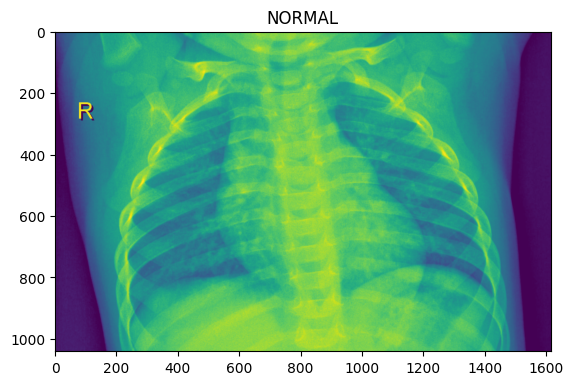

In [39]:
img=mpimg.imread(image)
imgplot=plt.imshow(img)
plt.title(CATEGORIES[int(prediction[0][0])])
plt.show()

In [41]:
# importing necessary libraries
import os
import cv2
import numpy as np
import tensorflow as tf
from keras.models import load_model

# set the path for test data
test_dir = "/content/chest_xray/test"

# define categories
CATEGORIES = ["NORMAL", "PNEUMONIA"]

# set image size
img_size = 100

# load the saved model
model = load_model('/content/drive/MyDrive/Copy of chest_xray-20250726T110654Z-1-001/chest_xray/model_10.h5')

# initialize lists for storing test data
X_test = []
y_test = []

# loop through the test data directory and extract the images and their labels
for category in CATEGORIES:
    path = os.path.join(test_dir, category)
    class_num = CATEGORIES.index(category)
    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
            new_array = cv2.resize(img_array, (img_size, img_size))
            X_test.append(new_array)
            y_test.append(class_num)
        except Exception as e:
            pass

# convert test data to numpy arrays
X_test = np.array(X_test).reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

# normalize test data
X_test = X_test / 255.0

# calculate test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

# print test accuracy
print('Test accuracy:', test_acc)


20/20 - 13s - 648ms/step - accuracy: 0.7837 - loss: 1.3315
Test accuracy: 0.7836538553237915
